In [2]:
import numpy as np 
import pandas as pd
import matplotlib .pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split #containes functions for plitiing data into training and testing sets
from sklearn.linear_model import LinearRegression  #provides algorithm
from sklearn.metrics import mean_squared_error,r2_score   

In [4]:
df = pd.read_csv("healthcare_dataset2.csv")

print(df.head())
print(df.info())

            Name  Age  Gender Blood Type Medical Condition Date of Admission  \
0  Bobby JacksOn   30    Male         B-            Cancer        31-01-2024   
1   LesLie TErRy   62    Male         A+           Obesity        20-08-2019   
2    DaNnY sMitH   76  Female         A-           Obesity        22-09-2022   
3   andrEw waTtS   28  Female         O+          Diabetes        18-11-2020   
4  adrIENNE bEll   43  Female        AB+            Cancer        19-09-2022   

             Doctor                    Hospital Insurance Provider  \
0     Matthew Smith             Sons and Miller         Blue Cross   
1   Samantha Davies                     Kim Inc           Medicare   
2  Tiffany Mitchell                    Cook PLC              Aetna   
3       Kevin Wells  Hernandez Rogers and Vang,           Medicare   
4    Kathleen Hanna                 White-White              Aetna   

   Billing Amount  Room Number Admission Type Discharge Date   Medication  \
0     18856.28131    

In [6]:
print(df.isnull().sum())

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64


In [10]:
df = df.drop_duplicates()
df

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,31-01-2024,Matthew Smith,Sons and Miller,Blue Cross,18856.281310,328,Urgent,02-02-2024,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,20-08-2019,Samantha Davies,Kim Inc,Medicare,33643.327290,265,Emergency,26-08-2019,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,22-09-2022,Tiffany Mitchell,Cook PLC,Aetna,27955.096080,205,Emergency,07-10-2022,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,18-11-2020,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,18-12-2020,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,19-09-2022,Kathleen Hanna,White-White,Aetna,14238.317810,458,Urgent,09-10-2022,Penicillin,Abnormal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55495,eLIZABeTH jaCkSOn,42,Female,O+,Asthma,16-08-2020,Joshua Jarvis,Jones-Thompson,Blue Cross,2650.714952,417,Elective,15-09-2020,Penicillin,Abnormal
55496,KYle pEREz,61,Female,AB-,Obesity,23-01-2020,Taylor Sullivan,Tucker-Moyer,Cigna,31457.797310,316,Elective,01-02-2020,Aspirin,Normal
55497,HEATher WaNG,38,Female,B+,Hypertension,13-07-2020,Joe Jacobs DVM,"and Mahoney Johnson Vasquez,",UnitedHealthcare,27620.764720,347,Urgent,10-08-2020,Ibuprofen,Abnormal
55498,JENniFER JOneS,43,Male,O-,Arthritis,25-05-2019,Kimberly Curry,"Jackson Todd and Castro,",Medicare,32451.092360,321,Elective,31-05-2019,Ibuprofen,Abnormal


In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = [
    'Gender',
    'Blood Type',
    'Medical Condition',
    'Insurance Provider',
    'Admission Type',
    'Medication',
    'Test Results'
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])
df

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,1,5,2,31-01-2024,Matthew Smith,Sons and Miller,1,18856.281310,328,2,02-02-2024,3,2
1,LesLie TErRy,62,1,0,5,20-08-2019,Samantha Davies,Kim Inc,3,33643.327290,265,1,26-08-2019,1,1
2,DaNnY sMitH,76,0,1,5,22-09-2022,Tiffany Mitchell,Cook PLC,0,27955.096080,205,1,07-10-2022,0,2
3,andrEw waTtS,28,0,6,3,18-11-2020,Kevin Wells,"Hernandez Rogers and Vang,",3,37909.782410,450,0,18-12-2020,1,0
4,adrIENNE bEll,43,0,2,2,19-09-2022,Kathleen Hanna,White-White,0,14238.317810,458,2,09-10-2022,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55495,eLIZABeTH jaCkSOn,42,0,6,1,16-08-2020,Joshua Jarvis,Jones-Thompson,1,2650.714952,417,0,15-09-2020,4,0
55496,KYle pEREz,61,0,3,5,23-01-2020,Taylor Sullivan,Tucker-Moyer,2,31457.797310,316,0,01-02-2020,0,2
55497,HEATher WaNG,38,0,4,4,13-07-2020,Joe Jacobs DVM,"and Mahoney Johnson Vasquez,",4,27620.764720,347,2,10-08-2020,1,0
55498,JENniFER JOneS,43,1,7,0,25-05-2019,Kimberly Curry,"Jackson Todd and Castro,",3,32451.092360,321,0,31-05-2019,1,0


In [18]:
X = df[
    [
        'Age',
        'Gender',
        'Blood Type',
        'Medical Condition',
        'Billing Amount',
        'Admission Type',
        'Medication'
    ]
]

y = df['Test Results']

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

RandomForestClassifier()

In [24]:
y_pred = model.predict(X_test)

In [26]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.4135892304893578


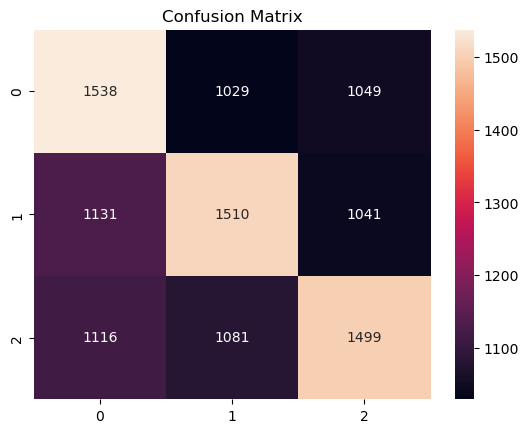

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")
plt.show()

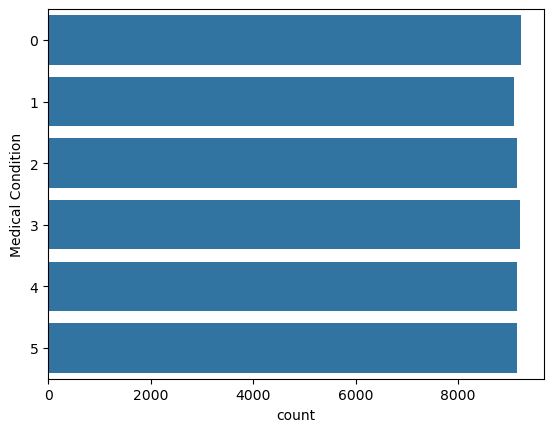

In [30]:
import seaborn as sns

sns.countplot(y='Medical Condition', data=df)
plt.show()

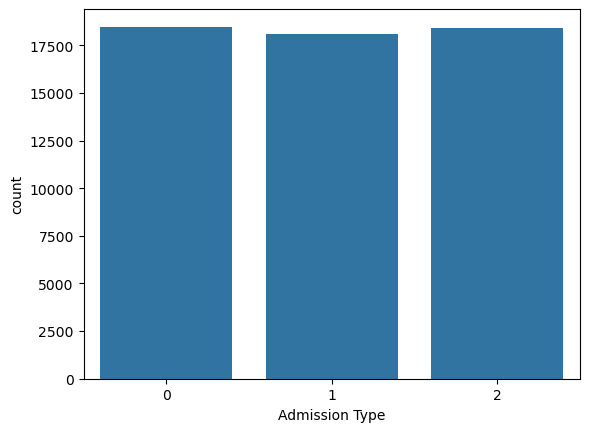

In [32]:
sns.countplot(x='Admission Type', data=df)
plt.show()

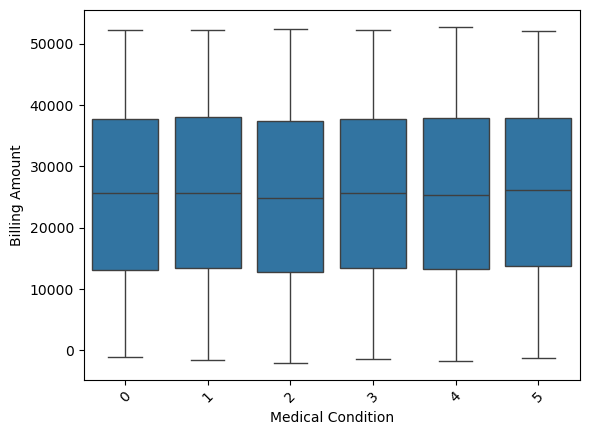

In [34]:
sns.boxplot(
    x='Medical Condition',
    y='Billing Amount',
    data=df
)

plt.xticks(rotation=45)
plt.show()